## 1. IMPORTACIÓN Y CONFIGURACIÓN

In [306]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime
from dateutil.relativedelta import relativedelta

from statsmodels.stats.diagnostic import linear_reset
# Librerías para ARIMA y validación
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox


import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
import optuna

# Configuraciones
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Fecha de análisis: 2025-12-05 23:30


## 2. CARGA DE DATOS

In [296]:
# Cargar datos del análisis exploratorio
try:
    with open('datasets_preparados.pkl', 'rb') as f:
        datasets = pickle.load(f)
    
    # Extraer datasets
    data = datasets['data']
    train_to1 = datasets['train_to1']
    train_to2 = datasets['train_to2']
    test_to1 = datasets['test_to1']
    test_to2 = datasets['test_to2']
    train_len = datasets['train_len']
    
    print("Datos cargados exitosamente")
    print(f"Configuración: {train_len} train / {len(data) - train_len} test")
    
except FileNotFoundError:
    print("Error: No se encontró 'datasets_preparados.pkl'")
    print("Ejecuta primero el notebook '01_Analisis_Exploratorio.ipynb'")

Datos cargados exitosamente
Configuración: 121 train / 6 test


## 3. TENDENCIA LINEAL

In [297]:
# Modelo de tendencia lineal para Producto 1
y = train_to1["producto1"].values  # Variable dependiente
x = np.arange(1, len(y) + 1)  # Variable independiente (índice temporal)
X = sm.add_constant(x)  # Añadir constante al modelo
lin = sm.OLS(y, X)  # Definir modelo de regresión lineal
lin_t = lin.fit()  # Ajustar modelo
print(lin_t.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     318.7
Date:               vie, 05 dic. 2025   Prob (F-statistic):           1.90e-35
Time:                        23:22:22   Log-Likelihood:                -640.60
No. Observations:                 121   AIC:                             1285.
Df Residuals:                     119   BIC:                             1291.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        490.8188      8.892     55.201      0.0

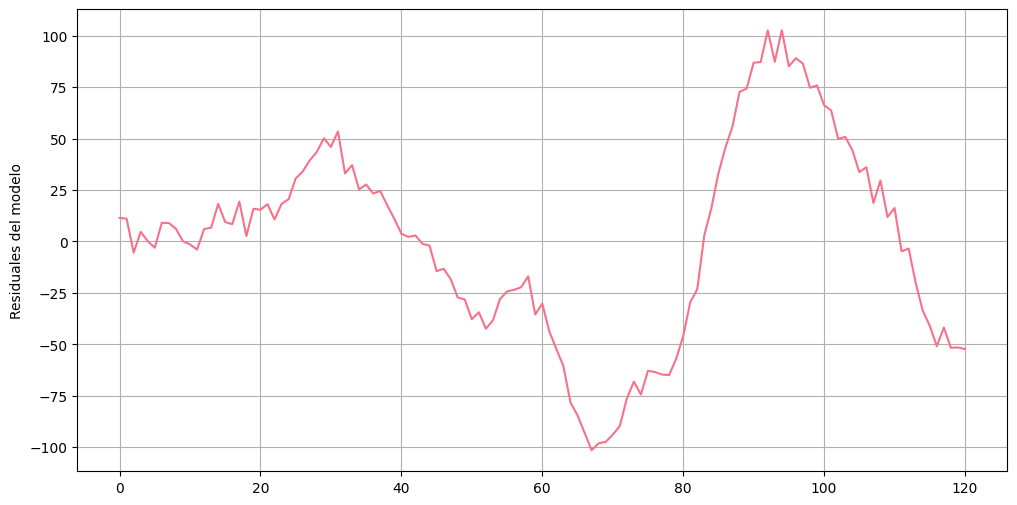

In [298]:
plt.ylabel("Residuales del modelo")
plt.plot(lin_t.resid)
plt.grid()

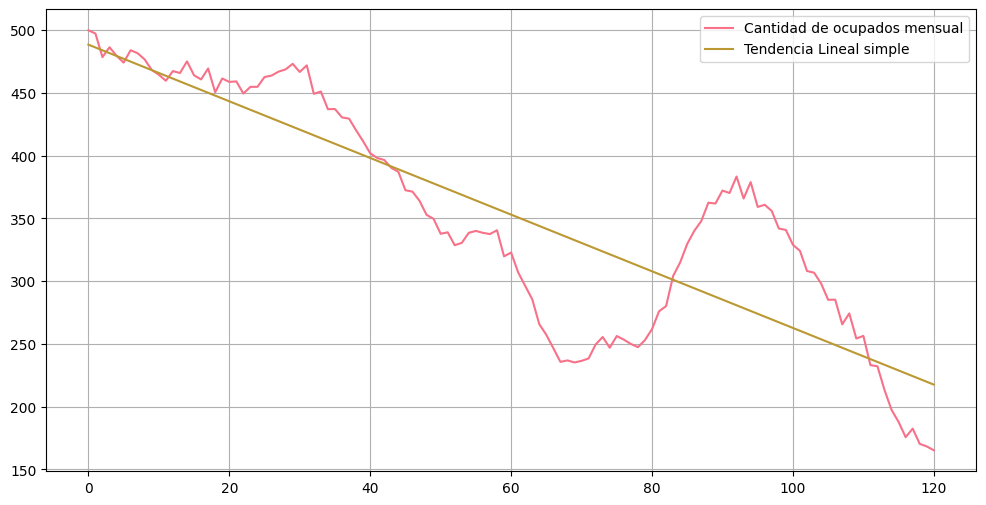

In [299]:
plt.plot(y,label="Cantidad de ocupados mensual")
plt.plot(lin_t.fittedvalues,label="Tendencia Lineal simple")
plt.legend(loc= "upper right")
plt.grid()
plt.show()

In [300]:
# Preparar datos para pronóstico (6 meses de test)
h = 6
x_for = np.arange(len(y) + 1, len(y) + h + 1)  # Índices después del entrenamiento
X_for = sm.add_constant(x_for)

In [301]:
dt = lin_t.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast    lower_95    upper_95
0      215.340842  117.509716  313.171969
1      213.082827  115.212271  310.953383
2      210.824811  112.914201  308.735421
3      208.566795  110.615507  306.518084
4      206.308780  108.316189  304.301370
5      204.050764  106.016249  302.085279


In [302]:
# Visualización de pronósticos con datos de test
plt.figure(figsize=(14, 6))
plt.plot(np.arange(1, len(y) + 1), y, label="Datos entrenamiento", linewidth=2)
plt.plot(np.arange(len(y) + 1, len(y) + len(test_to1['producto1']) + 1), 
         test_to1['producto1'].values, label="Datos test (reales)", 
         linewidth=2, color='green')
plt.plot(x_for, y_prd, label="Pronóstico tendencia lineal", 
         linewidth=2, linestyle='--', color='red')
plt.fill_between(x_for, yprd_ci_lower, yprd_ci_upper, 
                 alpha=0.2, color='red', label='IC 95%')
plt.axvline(x=len(y), color='black', linestyle='--', alpha=0.7)
plt.ylabel("Valores")
plt.xlabel("Tiempo")
plt.title("Pronósticos con Tendencia Lineal - Producto 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

KeyboardInterrupt: 

In [ ]:
rmse = np.sqrt(mean_squared_error(test_to1, y_prd))
print("RMSE del modelo lineal:", round(rmse, 2))

RMSE del modelo lineal: 58.29
 58.29


## 4. TENDENCIA CUADRÁTICA

In [ ]:
# Modelo de tendencia cuadrática para Producto 1
y_quad = train_to1["producto1"].values
train_to1["x"] = np.linspace(1, train_len, train_len)
train_to1["x2"] = train_to1["x"] ** 2
X_quad = sm.add_constant(train_to1[["x", "x2"]])  # Usar statsmodels para agregar constante
pol = sm.OLS(y_quad, X_quad)  # Modelo de regresión cuadrática
pol_2 = pol.fit()  # Ajustar modelo
print(pol_2.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     171.2
Date:               vie, 05 dic. 2025   Prob (F-statistic):           1.29e-35
Time:                        23:22:14   Log-Likelihood:                -637.02
No. Observations:                 121   AIC:                             1280.
Df Residuals:                     118   BIC:                             1288.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.3224     13.139     39.374      0.0

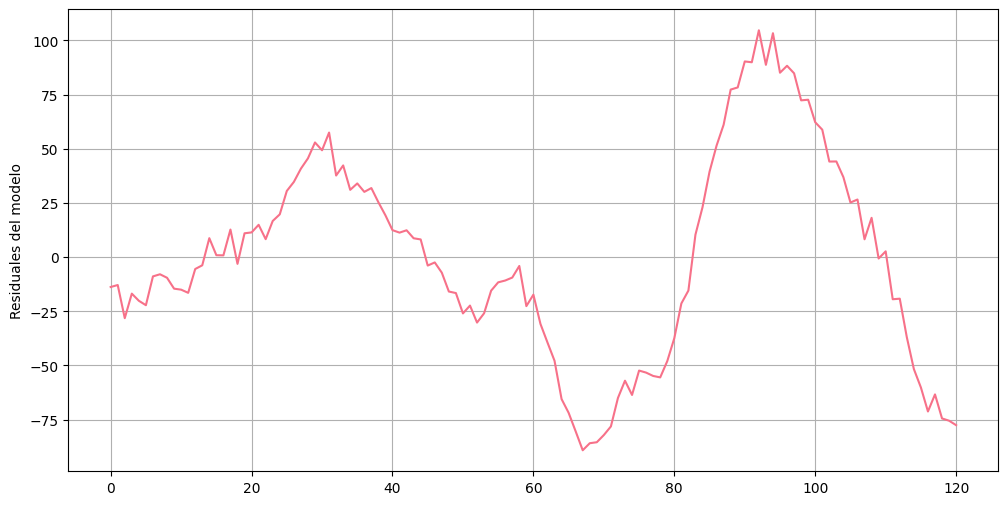

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_2.resid)
plt.grid()

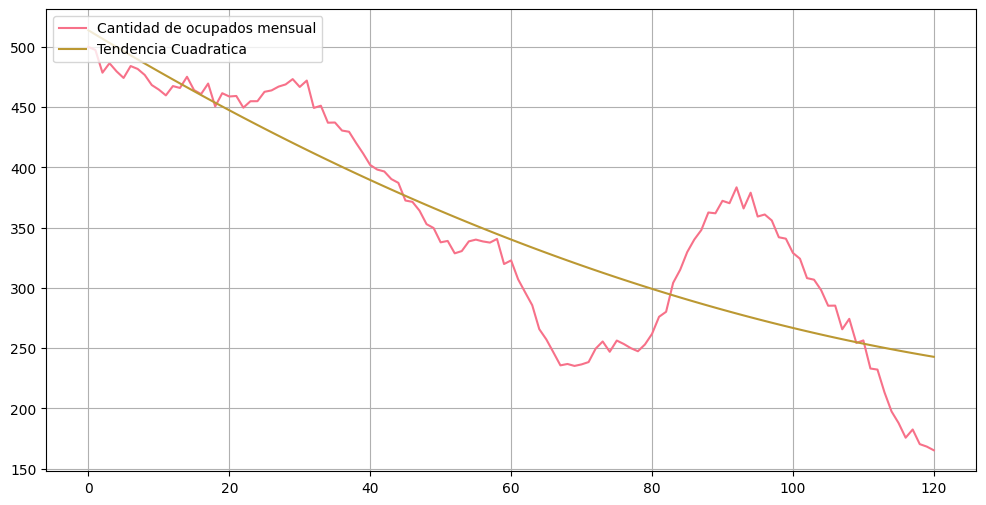

In [ ]:
plt.plot(y,label="Cantidad de ocupados mensual")
plt.plot(pol_2.fittedvalues,label="Tendencia Cuadratica")
plt.legend(loc= "upper left")
plt.grid()
plt.show()

In [ ]:
h = 6
x_for = np.linspace(train_to2.shape[0] + 1, train_to2.shape[0] + h, h)
X_for = sm.add_constant(np.stack((x_for, x_for**2), axis=1))

In [ ]:
dt = pol_2.get_prediction(X_for).summary_frame(alpha=0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame({
    'Point_forecast': y_prd,
    'lower_95': yprd_ci_lower,
    'upper_95': yprd_ci_upper
})

print(preds)

   Point_forecast    lower_95    upper_95
0      241.844477  144.477120  339.211833
1      240.889918  143.287343  338.492494
2      239.956554  142.105833  337.807276
3      239.044385  140.932223  337.156547
4      238.153410  139.766143  336.540677
5      237.283630  138.607230  335.960029


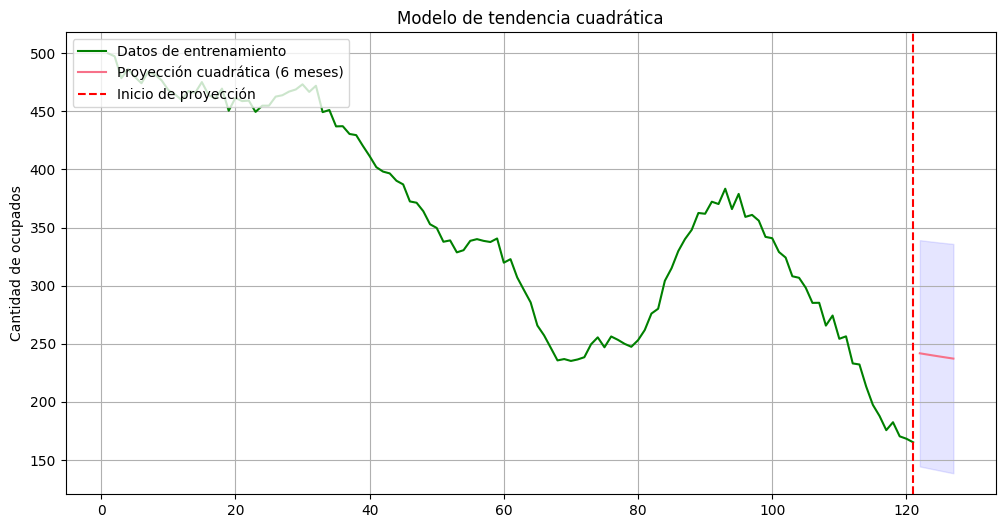

In [ ]:
fig = plt.figure(figsize=(12, 6))

# Eje X numérico para entrenamiento
x = np.arange(1, train_to1.shape[0] + 1)
y = train_to1["producto1"].values

# Serie real (entrenamiento)
plt.plot(x, y, label="Datos de entrenamiento", color="green")

# Predicción futura
x_future = np.arange(train_to1.shape[0] + 1, train_to1.shape[0] + 1 + len(preds))
plt.plot(x_future,preds['Point_forecast'],label="Proyección cuadrática (6 meses)")

# Intervalo de confianza
plt.fill_between(x_future,preds['lower_95'],preds['upper_95'],color='blue',alpha=0.1)

# Línea divisoria del inicio de proyección
plt.axvline(x=train_to1.shape[0], color='red',linestyle='--',linewidth=1.5,label='Inicio de proyección')

# Detalles del gráfico
plt.title("Modelo de tendencia cuadrática")
plt.ylabel("Cantidad de ocupados")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

In [ ]:
rmse_quad = np.sqrt(mean_squared_error(test_to1["producto1"], y_prd))
print("RMSE del modelo de tendencia cuadrática:", round(rmse_quad, 2))

RMSE del modelo de tendencia cuadrática: 88.16


TENDENCIA POLINÓMICA

In [ ]:
# Variables
y_train = train_to1["producto1"]
y_test = test_to1["producto1"]

# Crear variable de tiempo para ambos conjuntos
train_to1["x"] = np.linspace(1, train_to1.shape[0], train_to1.shape[0])
test_to1["x"] = np.linspace(train_to1.shape[0]+1, train_to1.shape[0]+test_to1.shape[0], test_to1.shape[0])
# Rango de grados polinómicos a probar
grados = [2, 3, 4, 5, 6, 7, 8, 9, 10]

resultados = {}

for g in grados:
    # Crear variable x^g en ambos conjuntos
    train_to1[f"x{g}"] = train_to1["x"] ** g
    test_to1[f"x{g}"] = test_to1["x"] ** g

    # Definir las variables predictoras y añadir constante
    X_train = sm.add_constant(train_to1[["x", f"x{g}"]])
    X_test = sm.add_constant(test_to1[["x", f"x{g}"]])

    # Entrenar modelo en train
    modelo = sm.OLS(y_train, X_train).fit()

    # Predecir sobre test
    y_pred_test = modelo.predict(X_test)

    # Calcular RMSE en test
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Guardar resultados
    resultados[g] = {
        "R² (train)": round(modelo.rsquared_adj, 4),
        "RMSE (test)": round(rmse, 2)
    }

# Mostrar tabla resumen
tabla_resultados = pd.DataFrame(resultados).T
tabla_resultados.index.name = "Grado del polinomio"
print(tabla_resultados)


                     R² (train)  RMSE (test)
Grado del polinomio                         
2                        0.7394        88.16
3                        0.7366        91.16
4                        0.7318        88.62
5                        0.7275        82.14
6                        0.7247        73.15
7                        0.7236        62.83
8                       -4.7665       285.36
9                      -13.3388       420.40
10                     -13.4951       427.39



Mejor grado polinómico: 7
RMSE en test: 62.83


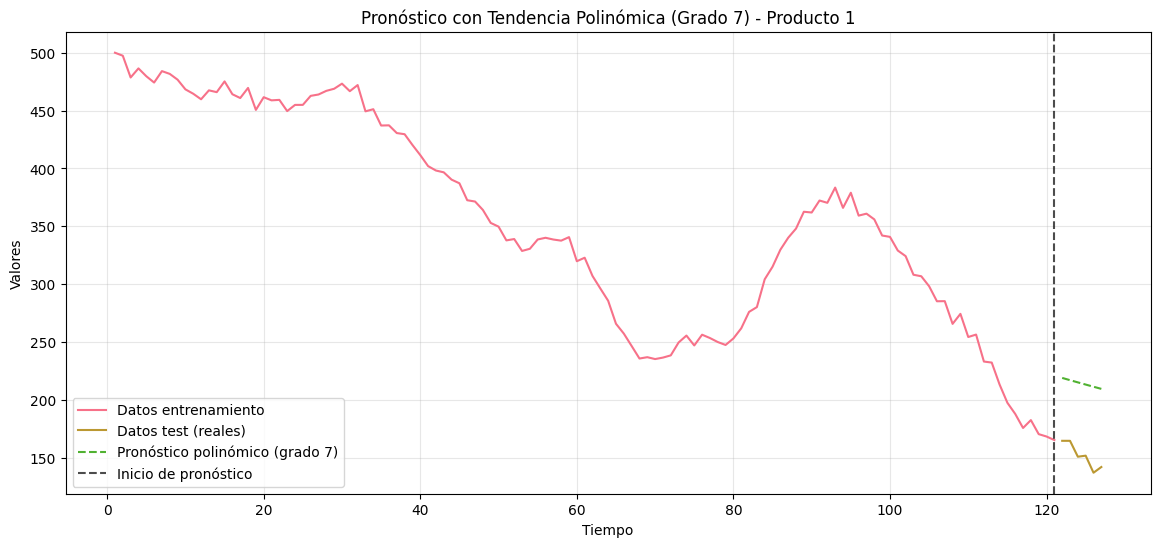

In [ ]:
# Identificar el mejor grado (menor RMSE en test)
mejor_grado = tabla_resultados['RMSE (test)'].idxmin()
print(f"\nMejor grado polinómico: {mejor_grado}")
print(f"RMSE en test: {tabla_resultados.loc[mejor_grado, 'RMSE (test)']}")

# Entrenar modelo final con el mejor grado
train_to1[f"x{mejor_grado}"] = train_to1["x"] ** mejor_grado
test_to1[f"x{mejor_grado}"] = test_to1["x"] ** mejor_grado

X_train_final = sm.add_constant(train_to1[["x", f"x{mejor_grado}"]])
X_test_final = sm.add_constant(test_to1[["x", f"x{mejor_grado}"]])

modelo_final = sm.OLS(y_train, X_train_final).fit()
y_pred_final = modelo_final.predict(X_test_final)

# Visualización
plt.figure(figsize=(14, 6))

# Datos de entrenamiento
x_train = np.arange(1, len(y_train) + 1)
plt.plot(x_train, y_train.values, label="Datos entrenamiento")

# Datos de test (reales)
x_test = np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1)
plt.plot(x_test, y_test.values, label="Datos test (reales)")

# Predicciones del modelo
plt.plot(x_test, y_pred_final, label=f"Pronóstico polinómico (grado {mejor_grado})", 
         linestyle='--')

# Línea divisoria
plt.axvline(x=len(y_train), color='black', linestyle='--', alpha=0.7, 
            label='Inicio de pronóstico')

plt.ylabel("Valores")
plt.xlabel("Tiempo")
plt.title(f"Pronóstico con Tendencia Polinómica (Grado {mejor_grado}) - Producto 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


ESTACIONALIDAD

In [ ]:
# Recargar datos originales para análisis de estacionalidad
with open('datasets_preparados.pkl', 'rb') as f:
    datasets = pickle.load(f)
train_estacional = datasets['train_to1'].copy()

# Crear índice datetime desde junio 2014
fecha_inicio = pd.Timestamp('2014-06-01')
train_estacional.index = pd.date_range(start=fecha_inicio, periods=len(train_estacional), freq='MS')

In [ ]:
# Crear las dummies mensuales (todas numéricas)
month_dummies = pd.get_dummies(train_estacional.index.month, prefix='mes', drop_first=True)
month_dummies.index = train_estacional.index
# Convertir a float explícitamente
month_dummies = month_dummies.astype(float)

In [ ]:
# Verificar el índice creado
print(f"Longitud del dataset: {len(train_estacional)}")
print(f"\nDistribución de meses:")
print(train_estacional.index.month.value_counts().sort_index())

Longitud del dataset: 121

Distribución de meses:
1     10
2     10
3     10
4     10
5     10
6     11
7     10
8     10
9     10
10    10
11    10
12    10
Name: count, dtype: int64


In [ ]:
# Definir las variables
y = train_estacional["producto1"].astype(float)
X = sm.add_constant(month_dummies)

# Ajustar modelo OLS
sea = sm.OLS(y, X)
season = sea.fit()

# Resultado
print(season.summary())

                            OLS Regression Results                            
Dep. Variable:              producto1   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.089
Method:                 Least Squares   F-statistic:                    0.1113
Date:               vie, 05 dic. 2025   Prob (F-statistic):               1.00
Time:                        23:22:14   Log-Likelihood:                -718.72
No. Observations:                 121   AIC:                             1461.
Df Residuals:                     109   BIC:                             1495.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        349.9488     30.624     11.427      0.0

In [ ]:
month_dummies

,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
2014-06-01,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-07-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2014-08-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2014-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2014-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2024-02-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-03-01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-04-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-05-01,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


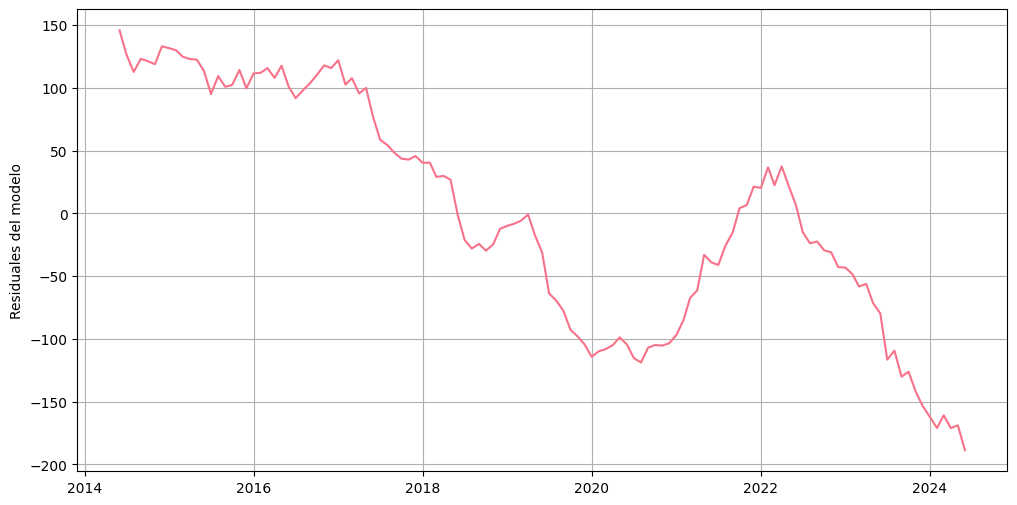

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(season.resid)
plt.grid()

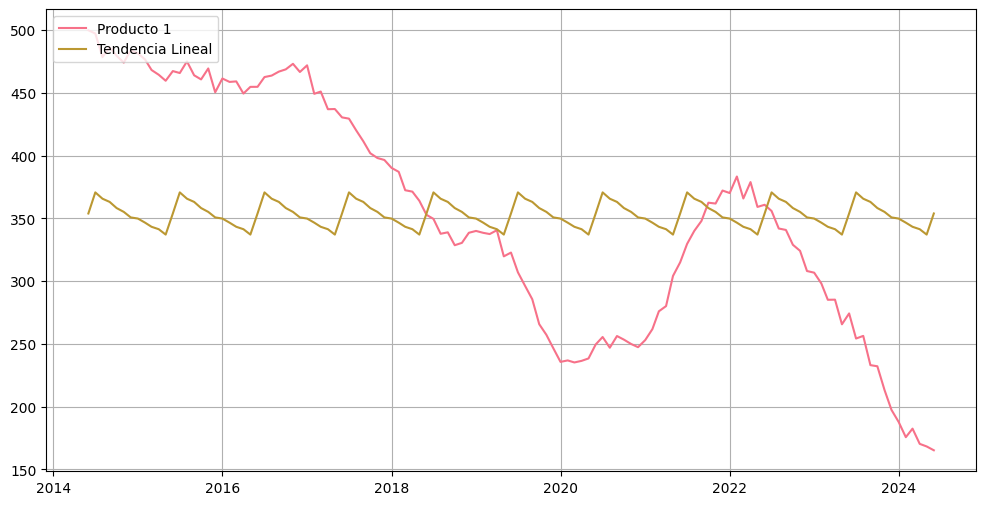

In [ ]:
plt.plot(y,label="Producto 1")
plt.plot(season.fittedvalues,label="Tendencia Lineal")
plt.legend(loc= "upper left")
plt.grid()
plt.show()

In [ ]:
# Generar fechas futuras para pronóstico (12 meses)
range_dates = pd.date_range(train_estacional.index[-1] + relativedelta(months=1), periods=12, freq='MS')

# Crear dummies mensuales para el pronóstico
x_for = pd.get_dummies(range_dates.month, drop_first=True).astype(float)
X_for = sm.add_constant(x_for)

In [ ]:
dt = season.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast    lower_95    upper_95
2024-07-01      370.805129  169.497868  572.112390
2024-08-01      365.766567  164.459306  567.073828
2024-09-01      363.212228  161.904966  564.519489
2024-10-01      358.318168  157.010906  559.625429
2024-11-01      355.254852  153.947590  556.562113
2024-12-01      350.861409  149.554148  552.168670
2025-01-01      349.948789  148.641527  551.256050
2025-02-01      346.674605  145.367344  547.981866
2025-03-01      343.387344  142.080082  544.694605
2025-04-01      341.465625  140.158364  542.772887
2025-05-01      337.177527  135.870266  538.484789
2025-06-01      353.993938  153.520251  554.467625


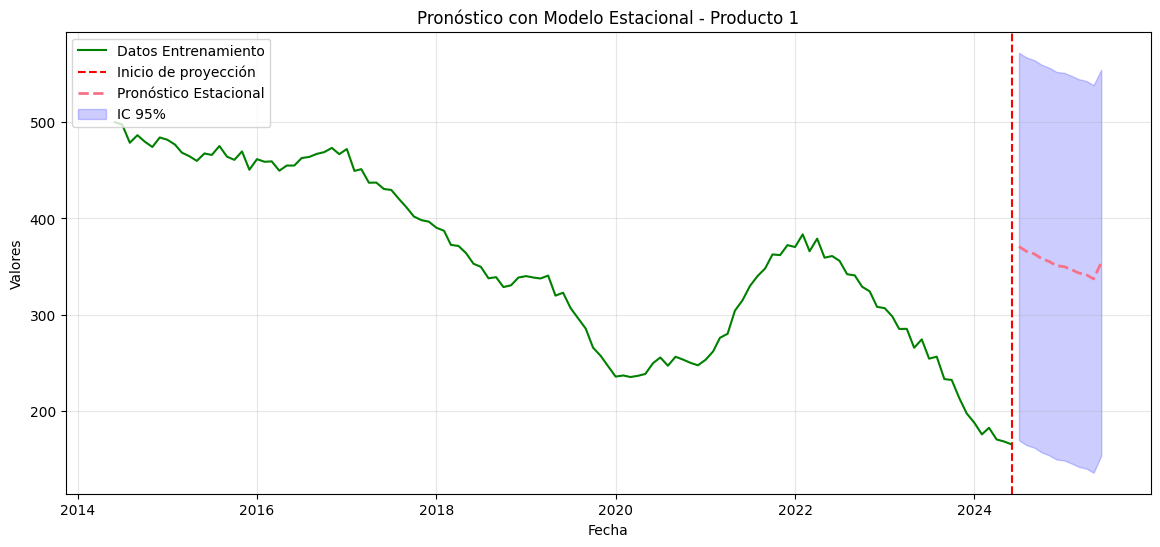

In [ ]:
# Visualización del pronóstico estacional
fig = plt.figure(figsize=(14, 6))

# Datos de entrenamiento con índice datetime
plt.plot(train_estacional.index, train_estacional["producto1"], label="Datos Entrenamiento", color="green")

# Línea divisoria
plt.axvline(train_estacional.index[-1], color='red', linestyle='--', label='Inicio de proyección')

# Pronósticos con intervalos de confianza
plt.plot(preds.index, preds['Point_forecast'], label="Pronóstico Estacional", linestyle='--', linewidth=2)
plt.fill_between(preds.index, preds['lower_95'], preds['upper_95'], color='blue', alpha=0.2, label='IC 95%')

plt.ylabel("Valores")
plt.xlabel("Fecha")
plt.title("Pronóstico con Modelo Estacional - Producto 1")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Predicciones dentro del conjunto de entrenamiento
dt_train = season.get_prediction().summary_frame(alpha=0.05)
y_pred_train = dt_train['mean']

# Cálculo del RMSE (comparando con los valores reales)
rmse = np.sqrt(mean_squared_error(train_estacional["producto1"], y_pred_train))

print(f"RMSE del modelo lineal estacional: {rmse:.2f}")

RMSE del modelo lineal estacional: 91.92


TENDENCIA + ESTACIONALIDAD

In [ ]:
y = train_estacional["producto1"]
train_estacional["x"] = np.linspace(1,train_estacional.shape[0],train_estacional.shape[0])
train_estacional["x6"] = train_estacional["x"]**6

month_dummies = pd.get_dummies(train_estacional.index.month,drop_first=True).set_index(train_estacional.index).astype(int)
X = sm.add_constant( pd.concat([train_estacional[["x","x6"]],month_dummies],axis=1) )

season_pol6 = sm.OLS(y,X)
season_pol6 = season_pol6.fit()
print(season_pol6.summary())

                            OLS Regression Results                            
Dep. Variable:              producto1   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     22.31
Date:               vie, 05 dic. 2025   Prob (F-statistic):           9.67e-25
Time:                        23:22:15   Log-Likelihood:                -640.06
No. Observations:                 121   AIC:                             1308.
Df Residuals:                     107   BIC:                             1347.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        493.6734     19.013     25.965      0.0

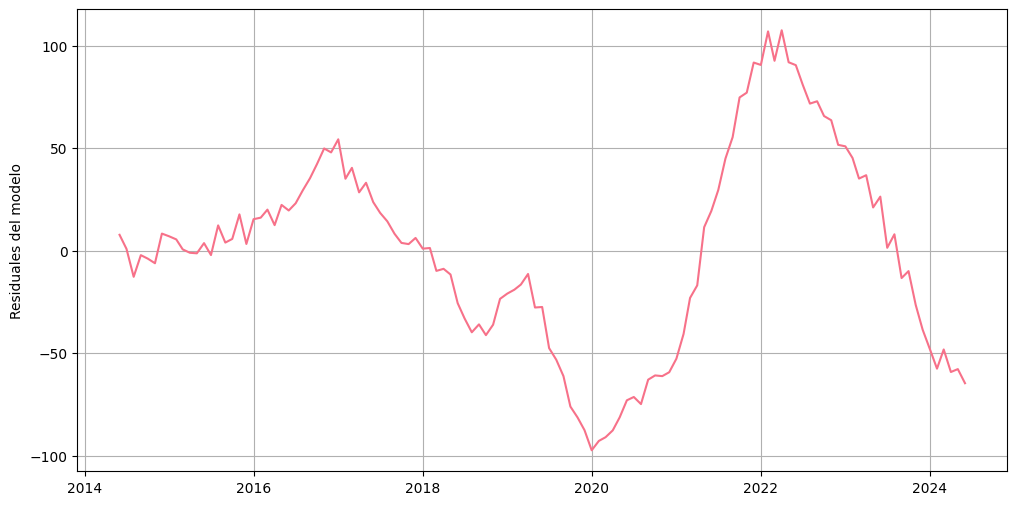

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(season_pol6.resid)
plt.grid()

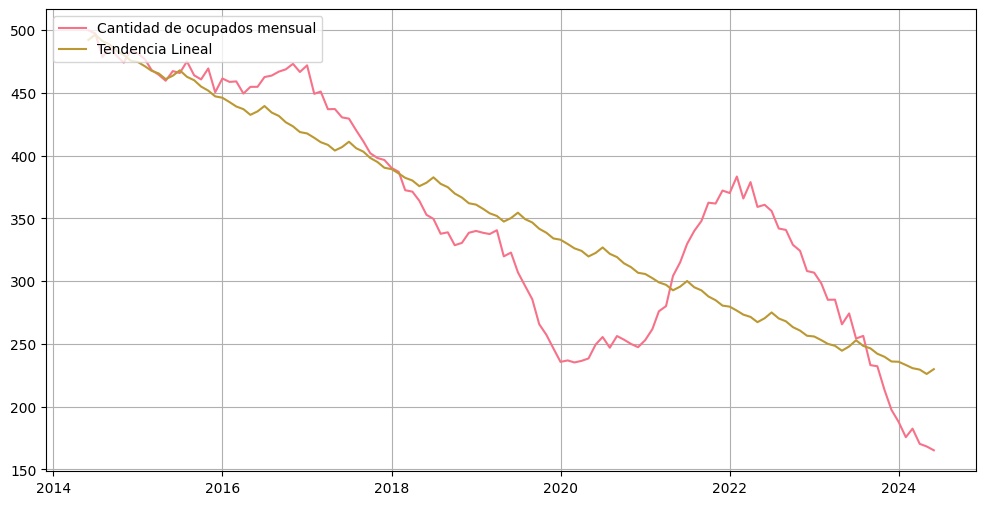

In [ ]:
plt.plot(y,label="Cantidad de ocupados mensual")
plt.plot(season_pol6.fittedvalues,label="Tendencia Lineal")
plt.legend(loc="upper left")
plt.grid()
plt.show()

In [ ]:
h=12
x_for= np.linspace((train_estacional.shape[0]+1),(train_estacional.shape[0]+h),h)
x_for_all = pd.DataFrame(np.stack((x_for, x_for**6),axis=1),columns=["x","x6"] )

range_dates = pd.date_range(train_estacional.index[-1]+ relativedelta(months=1), periods=h,freq='MS')
x_for_dummies = pd.get_dummies(range_dates.month,drop_first=True)

X_for= sm.add_constant(pd.concat([x_for_all,x_for_dummies],axis=1))
X_for

,const,x,x6,2,3,4,5,6,7,8,9,10,11,12
0,1.0,122.0,3.297304e+12,False,False,False,False,False,True,False,False,False,False,False
1,1.0,123.0,3.462826e+12,False,False,False,False,False,False,True,False,False,False,False
2,1.0,124.0,3.635215e+12,False,False,False,False,False,False,False,True,False,False,False
3,1.0,125.0,3.814697e+12,False,False,False,False,False,False,False,False,True,False,False
4,1.0,126.0,4.001504e+12,False,False,False,False,False,False,False,False,False,True,False
5,1.0,127.0,4.195873e+12,False,False,False,False,False,False,False,False,False,False,True
6,1.0,128.0,4.398047e+12,False,False,False,False,False,False,False,False,False,False,False
7,1.0,129.0,4.608274e+12,True,False,False,False,False,False,False,False,False,False,False
8,1.0,130.0,4.826809e+12,False,True,False,False,False,False,False,False,False,False,False
9,1.0,131.0,5.053913e+12,False,False,True,False,False,False,False,False,False,False,False


In [ ]:
dt = season_pol6.get_prediction(X_for.astype(int)).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
preds = preds.iloc[:6]
print(preds)

            Point_forecast    lower_95    upper_95
2024-07-01      235.316471  122.067175  348.565767
2024-08-01      231.307197  117.145475  345.468919
2024-09-01      229.823188  114.647910  344.998466
2024-10-01      226.041769  109.744721  342.338817
2024-11-01      224.134701  106.600425  341.668978
2024-12-01      220.942438  102.048098  339.836778


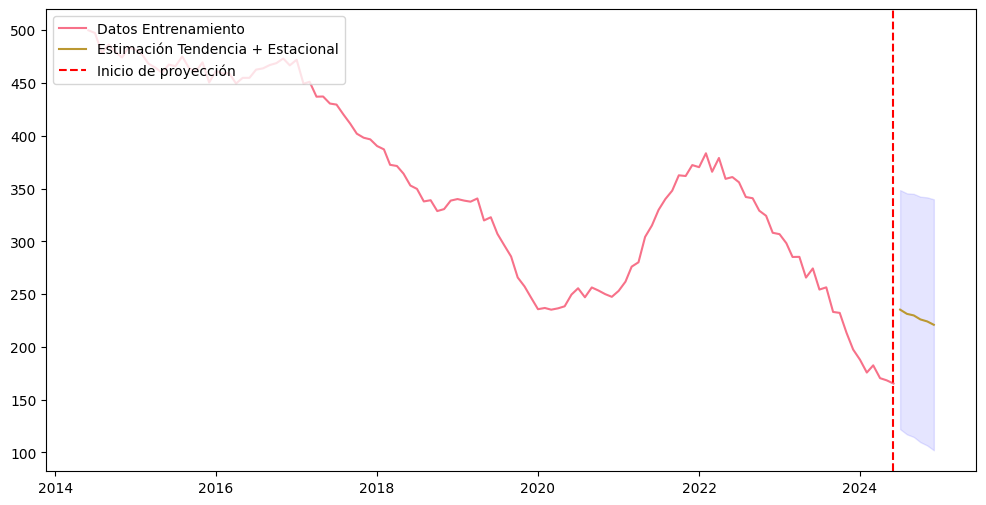

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.axvline(train_estacional.index[-1], color='red', linestyle='--', label='Inicio de proyección')
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend(loc="upper left")
plt.show()

In [ ]:
y_true = train_estacional["producto1"]
y_pred = season_pol6.fittedvalues

# cálculo del RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"RMSE del modelo tendencia + estacionalidad: {rmse:.2f}")

RMSE del modelo tendencia + estacionalidad: 47.98


## **Validación de supuestos** ##

In [308]:
# ==================== VALIDACIÓN DE SUPUESTOS DEL MODELO ====================
# Modelo: Tendencia Polinómica (grado 6) + Estacionalidad

print("="*70)
print("VALIDACIÓN DE SUPUESTOS - MODELO TENDENCIA + ESTACIONALIDAD")
print("="*70)

# Extraer residuos del modelo
residuos = season_pol6.resid

print(f"\n1. ESTADÍSTICAS DESCRIPTIVAS DE RESIDUOS")
print("-"*70)
print(f"   Media de residuos: {residuos.mean():.6f}")
print(f"   Desviación estándar: {residuos.std():.4f}")
print(f"   Mínimo: {residuos.min():.4f}")
print(f"   Máximo: {residuos.max():.4f}")

# ==================== SUPUESTO 1: NORMALIDAD DE RESIDUOS ====================
print(f"\n2. SUPUESTO DE NORMALIDAD")
print("-"*70)

# Test de Jarque-Bera
jb_stat, jb_pvalue = stats.jarque_bera(residuos)
print(f"   Test Jarque-Bera:")
print(f"      Estadístico: {jb_stat:.4f}")
print(f"      p-value: {jb_pvalue:.4f}")
if jb_pvalue > 0.05:
    print(f"      ✓ No se rechaza normalidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza normalidad (p ≤ 0.05)")

# Test de Shapiro-Wilk (más robusto para muestras pequeñas)
sw_stat, sw_pvalue = stats.shapiro(residuos)
print(f"\n   Test Shapiro-Wilk:")
print(f"      Estadístico: {sw_stat:.4f}")
print(f"      p-value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print(f"      ✓ No se rechaza normalidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza normalidad (p ≤ 0.05)")

# ==================== SUPUESTO 2: HOMOCEDASTICIDAD ====================
print(f"\n3. SUPUESTO DE HOMOCEDASTICIDAD (Varianza Constante)")
print("-"*70)

# Test de Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

# Reconstruir X para el test
y_test = train_estacional["producto1"]
month_dummies_test = pd.get_dummies(train_estacional.index.month, drop_first=True).set_index(train_estacional.index).astype(int)
X_test = sm.add_constant(pd.concat([train_estacional[["x", "x6"]], month_dummies_test], axis=1))

bp_stat, bp_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(residuos, X_test)
print(f"   Test Breusch-Pagan:")
print(f"      Estadístico LM: {bp_stat:.4f}")
print(f"      p-value: {bp_pvalue:.4f}")
if bp_pvalue > 0.05:
    print(f"      ✓ No se rechaza homocedasticidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza homocedasticidad - posible heterocedasticidad (p ≤ 0.05)")

# ==================== SUPUESTO 3: INDEPENDENCIA (NO AUTOCORRELACIÓN) ====================
print(f"\n4. SUPUESTO DE INDEPENDENCIA (No Autocorrelación)")
print("-"*70)

# Test de Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(residuos)
print(f"   Test Durbin-Watson:")
print(f"      Estadístico DW: {dw_stat:.4f}")
print(f"      Interpretación:")
if 1.5 < dw_stat < 2.5:
    print(f"      ✓ No hay autocorrelación significativa (1.5 < DW < 2.5)")
elif dw_stat < 1.5:
    print(f"      ✗ Posible autocorrelación positiva (DW < 1.5)")
else:
    print(f"      ✗ Posible autocorrelación negativa (DW > 2.5)")

# Test de Ljung-Box (autocorrelación en múltiples lags)
ljung_box_result = acorr_ljungbox(residuos, lags=10, return_df=True)
print(f"\n   Test Ljung-Box (Autocorrelación hasta lag 10):")
print(f"      p-value (lag 10): {ljung_box_result['lb_pvalue'].iloc[-1]:.4f}")
if ljung_box_result['lb_pvalue'].iloc[-1] > 0.05:
    print(f"      ✓ No se detecta autocorrelación significativa (p > 0.05)")
    print(f"      Los residuos parecen ruido blanco")
else:
    print(f"      ✗ Se detecta autocorrelación (p ≤ 0.05)")
    print(f"      Posibles patrones temporales en residuos")

# ==================== SUPUESTO 4: LINEALIDAD ====================
print(f"\n5. SUPUESTO DE LINEALIDAD")
print("-"*70)

# Test RESET de Ramsey
reset_result = linear_reset(season_pol6, power=2, test_type='fitted', use_f=True)
reset_stat = reset_result.statistic
reset_pvalue = reset_result.pvalue

print(f"   Test RESET de Ramsey:")
print(f"      Estadístico F: {reset_stat:.4f}")
print(f"      p-value: {reset_pvalue:.4f}")
if reset_pvalue > 0.05:
    print(f"      ✓ No se rechaza especificación lineal (p > 0.05)")
    print(f"      El modelo parece bien especificado")
else:
    print(f"      ✗ Posible no linealidad o mala especificación (p ≤ 0.05)")

# ==================== RESUMEN GENERAL ====================
print(f"\n" + "="*70)
print("RESUMEN DE VALIDACIÓN DE SUPUESTOS")
print("="*70)

supuestos_cumplidos = []
supuestos_no_cumplidos = []

if jb_pvalue > 0.05 and sw_pvalue > 0.05:
    supuestos_cumplidos.append("✓ Normalidad de residuos")
else:
    supuestos_no_cumplidos.append("✗ Normalidad de residuos")

if bp_pvalue > 0.05:
    supuestos_cumplidos.append("✓ Homocedasticidad")
else:
    supuestos_no_cumplidos.append("✗ Homocedasticidad")

if 1.5 < dw_stat < 2.5 and ljung_box_result['lb_pvalue'].iloc[-1] > 0.05:
    supuestos_cumplidos.append("✓ Independencia (No autocorrelación)")
else:
    supuestos_no_cumplidos.append("✗ Independencia (Autocorrelación detectada)")

if reset_pvalue > 0.05:
    supuestos_cumplidos.append("✓ Especificación lineal correcta")
else:
    supuestos_no_cumplidos.append("✗ Especificación del modelo")

print("\nSupuestos CUMPLIDOS:")
for supuesto in supuestos_cumplidos:
    print(f"   {supuesto}")

if supuestos_no_cumplidos:
    print("\nSupuestos NO CUMPLIDOS:")
    for supuesto in supuestos_no_cumplidos:
        print(f"   {supuesto}")

print("\n" + "="*70)
if len(supuestos_cumplidos) >= 3:
    print("CONCLUSIÓN: El modelo cumple la mayoría de supuestos")
    print("Los resultados son confiables para inferencia y pronóstico")
else:
    print("CONCLUSIÓN: Varios supuestos no se cumplen")
    print("Considerar transformaciones o modelos alternativos")
print("="*70)

VALIDACIÓN DE SUPUESTOS - MODELO TENDENCIA + ESTACIONALIDAD

1. ESTADÍSTICAS DESCRIPTIVAS DE RESIDUOS
----------------------------------------------------------------------
   Media de residuos: 0.000418
   Desviación estándar: 48.1803
   Mínimo: -97.3449
   Máximo: 107.4420

2. SUPUESTO DE NORMALIDAD
----------------------------------------------------------------------
   Test Jarque-Bera:
      Estadístico: 1.3024
      p-value: 0.5214
      ✓ No se rechaza normalidad (p > 0.05)

   Test Shapiro-Wilk:
      Estadístico: 0.9839
      p-value: 0.1582
      ✓ No se rechaza normalidad (p > 0.05)

3. SUPUESTO DE HOMOCEDASTICIDAD (Varianza Constante)
----------------------------------------------------------------------
   Test Breusch-Pagan:
      Estadístico LM: 43.7442
      p-value: 0.0000
      ✗ Se rechaza homocedasticidad - posible heterocedasticidad (p ≤ 0.05)

4. SUPUESTO DE INDEPENDENCIA (No Autocorrelación)
----------------------------------------------------------------------


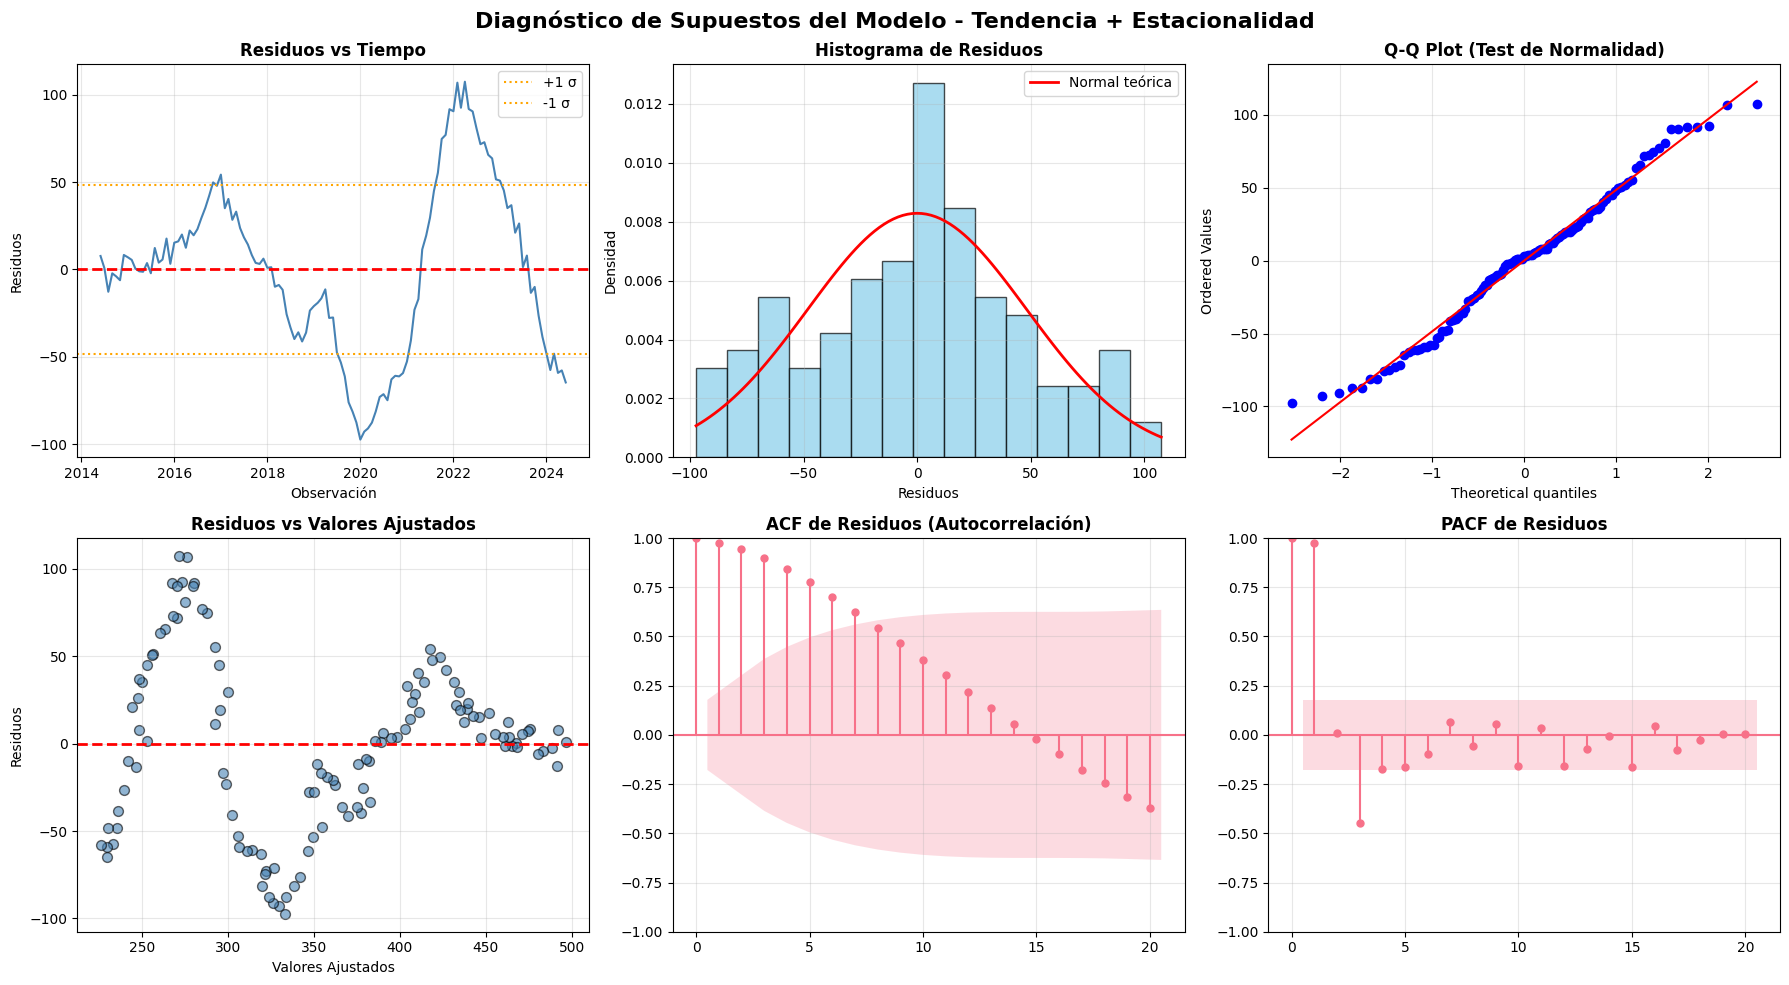

In [310]:
# ==================== VISUALIZACIÓN DE SUPUESTOS ====================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Diagnóstico de Supuestos del Modelo - Tendencia + Estacionalidad', 
             fontsize=16, fontweight='bold')

# 1. Residuos vs Tiempo
axes[0, 0].plot(residuos, color='steelblue', linewidth=1.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].axhline(y=residuos.std(), color='orange', linestyle=':', linewidth=1.5, label='+1 σ')
axes[0, 0].axhline(y=-residuos.std(), color='orange', linestyle=':', linewidth=1.5, label='-1 σ')
axes[0, 0].set_title('Residuos vs Tiempo', fontweight='bold')
axes[0, 0].set_xlabel('Observación')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Histograma de Residuos
axes[0, 1].hist(residuos, bins=15, color='skyblue', edgecolor='black', alpha=0.7, density=True)
# Superponer distribución normal
mu, sigma = residuos.mean(), residuos.std()
x = np.linspace(residuos.min(), residuos.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal teórica')
axes[0, 1].set_title('Histograma de Residuos', fontweight='bold')
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q Plot (Normalidad)
stats.probplot(residuos, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Test de Normalidad)', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# 4. Residuos vs Valores Ajustados (Homocedasticidad)
fitted_values = season_pol6.fittedvalues
axes[1, 0].scatter(fitted_values, residuos, alpha=0.6, color='steelblue', edgecolors='black', s=50)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[1, 0].set_xlabel('Valores Ajustados')
axes[1, 0].set_ylabel('Residuos')
axes[1, 0].grid(alpha=0.3)

# 5. ACF de Residuos (Autocorrelación)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos, lags=20, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF de Residuos (Autocorrelación)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# 6. PACF de Residuos
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(residuos, lags=20, ax=axes[1, 2], alpha=0.05)
axes[1, 2].set_title('PACF de Residuos', fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4. FUNCIÓN ARIMA MEJORADA

In [ ]:
# ==================== FUNCIÓN ARIMA CON VALIDACIONES ROBUSTAS ====================

def evaluar_expanding_forecast_arima(serie, order, window=12, step_size=1, horizon=1, metric='rmse'):
    """
    Simula pronósticos ARIMA en tiempo real con ventana expandida desde el inicio.
    Incluye validaciones de supuestos ARIMA mejoradas.
    
    Parameters:
    -----------
    serie : pd.Series
        Serie de tiempo a modelar
    order : tuple
        Orden ARIMA (p, d, q)
    window : int
        Número de puntos de validación
    step_size : int
        Tamaño del paso para validación
    horizon : int
        Horizonte de pronóstico
    metric : str
        Métrica de evaluación ('rmse' o 'mae')
    
    Returns:
    --------
    float
        Valor de la métrica de error
    """
    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)
    predichos = []
    observados = []
    p, d, q = order
    
    # Validación básica de parámetros
    if p < 0 or d < 0 or q < 0 or p > 5 or d > 2 or q > 5:
        return np.inf
    
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))
    
    if len(puntos_finales) == 0:
        return np.inf
    
    for end_train in puntos_finales:
        train = serie.iloc[:end_train]
        test = serie.iloc[end_train:end_train + horizon]
        
        # Validaciones básicas
        if len(test) < horizon or test.isna().any() or len(train) < max(10, p + d + q + 5):
            continue
        
        try:
            # Suprimir warnings durante la optimización
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                
                # Configuración del modelo ARIMA con mejor manejo
                model = ARIMA(
                    train,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                    concentrate_scale=True  # Mejora la estabilidad numérica
                )
                
                fitted_model = model.fit(
                    method_kwargs={"warn_convergence": False},
                    low_memory=True
                )
                
                # Verificar convergencia del modelo
                if not fitted_model.mle_retvals['converged']:
                    continue
                    
                pred = fitted_model.forecast(steps=horizon)
                
                # Validar predicciones
                if not np.isfinite(pred).all() or np.any(np.abs(pred) > 1e6):
                    continue
                    
        except Exception as e:
            # Capturar errores específicos comunes
            if any(x in str(e) for x in ['singular', 'convergence', 'invert']):
                continue
            else:
                continue
        
        pred = pd.Series(pred).astype(float)
        mask = (~pred.isna()) & (~test.isna())
        
        if mask.sum() == 0:
            continue
        
        predichos.extend(pred[mask].tolist())
        observados.extend(test[mask].tolist())
    
    if len(predichos) == 0:
        return np.inf
    
    predichos = np.array(predichos, dtype=float)
    observados = np.array(observados, dtype=float)
    
    mask_finite = np.isfinite(predichos) & np.isfinite(observados)
    
    if mask_finite.sum() == 0:
        return np.inf
    
    predichos = predichos[mask_finite]
    observados = observados[mask_finite]
    
    # Penalizar si muy pocas predicciones válidas
    if len(predichos) < max(3, window // 3):
        return np.inf
    
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    elif metric == 'mae':
        return np.mean(np.abs(observados - predichos))
    else:
        raise ValueError("Metric must be 'rmse' or 'mae'")

print("Función ARIMA mejorada definida")

Función ARIMA mejorada definida


## 5. OPTIMIZACIÓN ARIMA - PRODUCTO 1

In [ ]:
# Función objetivo para optimización ARIMA - Producto 1
def objective_arima_p1(trial):
    """Función objetivo mejorada para optimización de ARIMA - Producto 1"""
    p = trial.suggest_int("p", 0, 4)  # Reducir rango para estabilidad
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 4)  # Reducir rango para estabilidad
    
    # Evitar combinaciones problemáticas
    if p + q > 6:  # Evitar modelos muy complejos
        return np.inf
    
    if p == 0 and q == 0 and d == 0:  # Modelo trivial
        return np.inf
        
    order = (p, d, q)
    return evaluar_expanding_forecast_arima(
        train_to1["producto1"],
        order,
        window=8,  # Aumentar ventana para más estabilidad
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("OPTIMIZACIÓN ARIMA - PRODUCTO 1")
print("=" * 50)
print("Iniciando optimización con Optuna...")
print("Con validaciones mejoradas y supuestos verificados")
print("-" * 60)

study_arima_p1 = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner()  # Pruning para eficiencia
)
study_arima_p1.optimize(objective_arima_p1, n_trials=100, timeout=600)  # Más trials con timeout

best_order_p1 = (
    study_arima_p1.best_params['p'],
    study_arima_p1.best_params['d'],
    study_arima_p1.best_params['q']
)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 1")
print("=" * 60)
print(f"Mejor RMSE: {study_arima_p1.best_value:.4f}")
print(f"Mejor orden ARIMA: {best_order_p1}")
print(f"Número de trials completados: {len(study_arima_p1.trials)}")
print(f"Número de trials exitosos: {len([t for t in study_arima_p1.trials if t.state.name == 'COMPLETE' and t.value < np.inf])}")
print("=" * 60)

[I 2025-12-05 23:22:16,163] A new study created in memory with name: no-name-0a4840eb-e2df-4f19-bcad-a5f899bed166


OPTIMIZACIÓN ARIMA - PRODUCTO 1
Iniciando optimización con Optuna...
Con validaciones mejoradas y supuestos verificados
------------------------------------------------------------


[I 2025-12-05 23:22:17,229] Trial 0 finished with value: 7.834700400780403 and parameters: {'p': 4, 'd': 0, 'q': 2}. Best is trial 0 with value: 7.834700400780403.
[I 2025-12-05 23:22:17,319] Trial 1 finished with value: 7.397037095510676 and parameters: {'p': 4, 'd': 1, 'q': 0}. Best is trial 1 with value: 7.397037095510676.
[I 2025-12-05 23:22:17,319] Trial 1 finished with value: 7.397037095510676 and parameters: {'p': 4, 'd': 1, 'q': 0}. Best is trial 1 with value: 7.397037095510676.
[I 2025-12-05 23:22:17,536] Trial 2 finished with value: 7.600779781104268 and parameters: {'p': 2, 'd': 1, 'q': 2}. Best is trial 1 with value: 7.397037095510676.
[I 2025-12-05 23:22:17,536] Trial 3 finished with value: inf and parameters: {'p': 4, 'd': 1, 'q': 4}. Best is trial 1 with value: 7.397037095510676.
[I 2025-12-05 23:22:17,536] Trial 2 finished with value: 7.600779781104268 and parameters: {'p': 2, 'd': 1, 'q': 2}. Best is trial 1 with value: 7.397037095510676.
[I 2025-12-05 23:22:17,536] Tr

KeyboardInterrupt: 

## 6. VISUALIZACIÓN Y ANÁLISIS DE SUPUESTOS - PRODUCTO 1

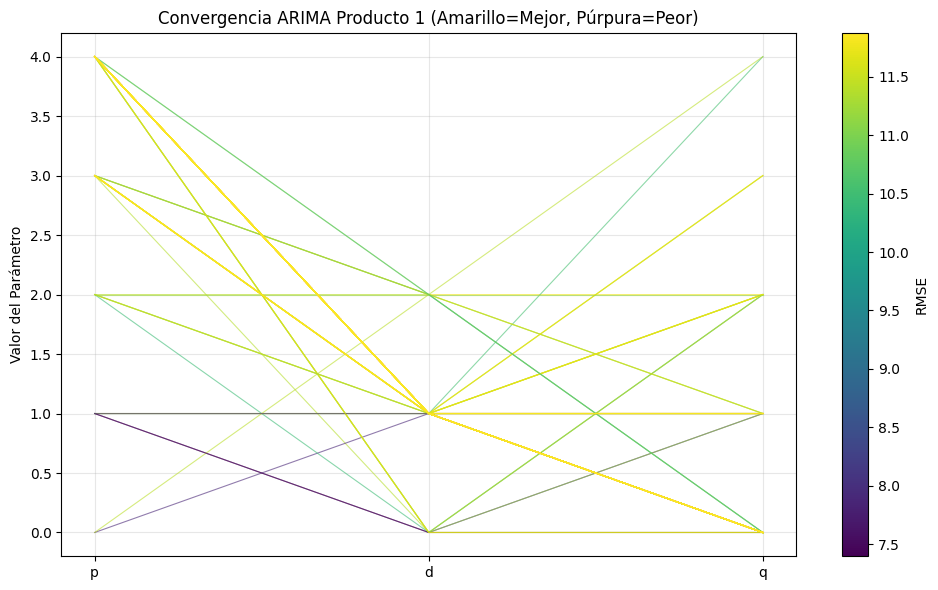


ANÁLISIS DE SUPUESTOS DEL MEJOR MODELO ARIMA - PRODUCTO 1
Modelo: ARIMA(4, 1, 0)
RMSE: 7.3970
Trials válidos: 93 de 100

VALIDACIONES DEL MODELO:
   - Modelo convergió: True
   - Log-likelihood: -409.84
   - AIC: 829.67
   - BIC: 843.61

SUPUESTOS ESTADÍSTICOS:
   - Test Ljung-Box (p-value): 1.0000
     Residuos parecen ruido blanco
   - Test Jarque-Bera normalidad (p-value): 0.0000
     Residuos no son normales


In [ ]:
# Visualización de Convergencia ARIMA Producto 1

# Extraer datos de los trials completados
trials_df = pd.DataFrame([
    {**trial.params, 'rmse': trial.value}
    for trial in study_arima_p1.trials
    if trial.state.name == 'COMPLETE' and trial.value < np.inf
])

if len(trials_df) > 0:
    # Crear gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Configurar coordenadas
    params = ['p', 'd', 'q']
    x_pos = np.arange(len(params))
    rmse_values = trials_df['rmse'].values
    colors = plt.cm.viridis(1 - (rmse_values - rmse_values.min()) / (rmse_values.max() - rmse_values.min()))
    
    # Dibujar líneas
    for i, row in trials_df.iterrows():
        y_values = [row[param] for param in params]
        ax.plot(x_pos, y_values, color=colors[i], alpha=0.6, linewidth=0.8)
    
    # Configuración
    ax.set_xticks(x_pos)
    ax.set_xticklabels(params)
    ax.set_ylabel('Valor del Parámetro')
    ax.set_title('Convergencia ARIMA Producto 1 (Amarillo=Mejor, Púrpura=Peor)')
    ax.grid(True, alpha=0.3)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=rmse_values.min(), vmax=rmse_values.max()))
    plt.colorbar(sm, ax=ax, label='RMSE')
    
    plt.tight_layout()
    plt.show()
    
    # Análisis de supuestos del mejor modelo ARIMA
    print(f"\n{'='*60}")
    print("ANÁLISIS DE SUPUESTOS DEL MEJOR MODELO ARIMA - PRODUCTO 1")
    print(f"{'='*60}")
    print(f"Modelo: ARIMA{best_order_p1}")
    print(f"RMSE: {study_arima_p1.best_value:.4f}")
    print(f"Trials válidos: {len(trials_df)} de {len(study_arima_p1.trials)}")
    
    # Entrenar modelo final para análisis
    try:
        final_model = ARIMA(train_to1["producto1"], order=best_order_p1).fit()
        
        print(f"\nVALIDACIONES DEL MODELO:")
        print(f"   - Modelo convergió: {final_model.mle_retvals['converged']}")
        print(f"   - Log-likelihood: {final_model.llf:.2f}")
        print(f"   - AIC: {final_model.aic:.2f}")
        print(f"   - BIC: {final_model.bic:.2f}")
        
        # Verificar residuos
        residuos = final_model.resid
        ljung_box = acorr_ljungbox(residuos, lags=10, return_df=True)
        p_value_ljung = ljung_box['lb_pvalue'].iloc[-1]
        
        print(f"\nSUPUESTOS ESTADÍSTICOS:")
        print(f"   - Test Ljung-Box (p-value): {p_value_ljung:.4f}")
        if p_value_ljung > 0.05:
            print("     Residuos parecen ruido blanco")
        else:
            print("     Posible autocorrelación en residuos")
            
        # Verificar normalidad de residuos
        _, p_norm = stats.jarque_bera(residuos)
        print(f"   - Test Jarque-Bera normalidad (p-value): {p_norm:.4f}")
        if p_norm > 0.05:
            print("     Residuos parecen normales")
        else:
            print("     Residuos no son normales")
            
        # Guardar modelo para usar después
        modelo_final_p1 = final_model
            
    except Exception as e:
        print(f"Error en análisis: {str(e)}")
        modelo_final_p1 = None
        
else:
    print("No se encontraron trials válidos para visualización")
    print("Esto puede indicar que los parámetros ARIMA necesitan ajuste")
    modelo_final_p1 = None

## 6. OPTIMIZACIÓN ARIMA - PRODUCTO 2

In [ ]:
# Función objetivo para optimización ARIMA - Producto 2
def objective_arima_p2(trial):
    """Función objetivo mejorada para optimización de ARIMA - Producto 2"""
    p = trial.suggest_int("p", 0, 4)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 4)
    
    # Evitar combinaciones problemáticas
    if p + q > 6:
        return np.inf
    
    if p == 0 and q == 0 and d == 0:
        return np.inf
        
    order = (p, d, q)
    return evaluar_expanding_forecast_arima(
        train_to2["producto2"],
        order,
        window=8,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("OPTIMIZACIÓN ARIMA - PRODUCTO 2")
print("=" * 50)
print("Iniciando optimización con Optuna...")
print("-" * 60)

study_arima_p2 = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner()
)
study_arima_p2.optimize(objective_arima_p2, n_trials=100, timeout=600)

best_order_p2 = (
    study_arima_p2.best_params['p'],
    study_arima_p2.best_params['d'],
    study_arima_p2.best_params['q']
)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 2")
print("=" * 60)
print(f"Mejor RMSE: {study_arima_p2.best_value:.4f}")
print(f"Mejor orden ARIMA: {best_order_p2}")
print(f"Número de trials completados: {len(study_arima_p2.trials)}")
print(f"Número de trials exitosos: {len([t for t in study_arima_p2.trials if t.state.name == 'COMPLETE' and t.value < np.inf])}")
print("=" * 60)

[I 2025-12-05 23:15:32,132] A new study created in memory with name: no-name-34e9e9b1-61fa-4352-9005-67d0ed02ffe4
[I 2025-12-05 23:15:32,135] Trial 0 finished with value: inf and parameters: {'p': 4, 'd': 1, 'q': 3}. Best is trial 0 with value: inf.
[I 2025-12-05 23:15:32,135] Trial 0 finished with value: inf and parameters: {'p': 4, 'd': 1, 'q': 3}. Best is trial 0 with value: inf.


OPTIMIZACIÓN ARIMA - PRODUCTO 2
Iniciando optimización con Optuna...
------------------------------------------------------------


[I 2025-12-05 23:15:33,440] Trial 1 finished with value: 10.682022780080825 and parameters: {'p': 2, 'd': 0, 'q': 2}. Best is trial 1 with value: 10.682022780080825.
[I 2025-12-05 23:15:33,440] Trial 2 finished with value: inf and parameters: {'p': 4, 'd': 1, 'q': 4}. Best is trial 1 with value: 10.682022780080825.
[I 2025-12-05 23:15:33,456] Trial 3 finished with value: inf and parameters: {'p': 0, 'd': 2, 'q': 0}. Best is trial 1 with value: 10.682022780080825.
[I 2025-12-05 23:15:33,440] Trial 2 finished with value: inf and parameters: {'p': 4, 'd': 1, 'q': 4}. Best is trial 1 with value: 10.682022780080825.
[I 2025-12-05 23:15:33,456] Trial 3 finished with value: inf and parameters: {'p': 0, 'd': 2, 'q': 0}. Best is trial 1 with value: 10.682022780080825.
[I 2025-12-05 23:15:33,823] Trial 4 finished with value: 8.480408378839105 and parameters: {'p': 3, 'd': 0, 'q': 0}. Best is trial 4 with value: 8.480408378839105.
[I 2025-12-05 23:15:33,847] Trial 5 finished with value: inf and p


RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 2
Mejor RMSE: 7.8960
Mejor orden ARIMA: (4, 0, 0)
Número de trials completados: 100
Número de trials exitosos: 91


## 7. ANÁLISIS DE SUPUESTOS - PRODUCTO 2

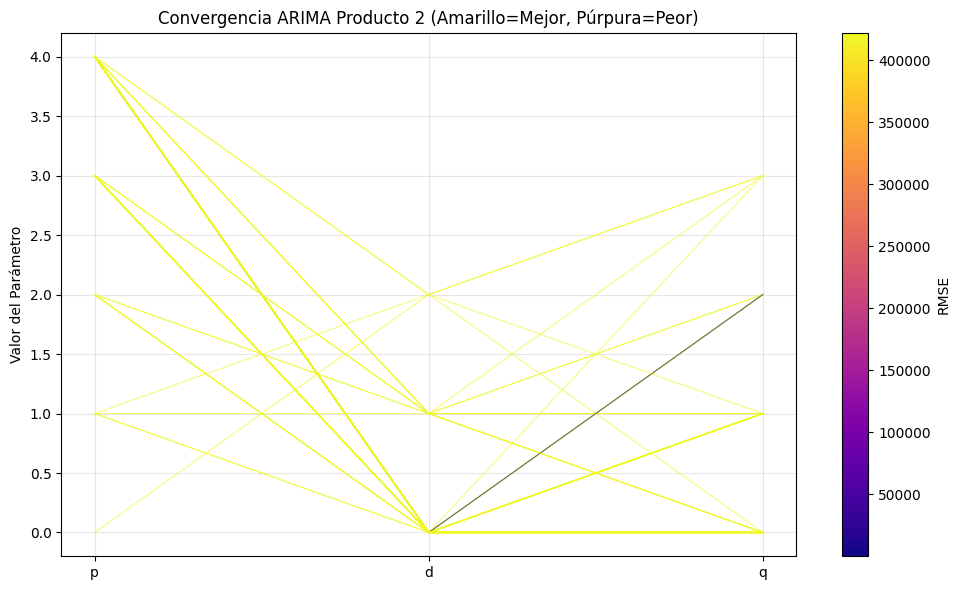


ANÁLISIS DE SUPUESTOS DEL MEJOR MODELO ARIMA - PRODUCTO 2
Modelo: ARIMA(4, 0, 0)
RMSE: 7.8960
Trials válidos: 91 de 100

VALIDACIONES DEL MODELO:
   - Modelo convergió: True
   - Log-likelihood: -450.80
   - AIC: 913.61
   - BIC: 930.38

SUPUESTOS ESTADÍSTICOS:
   - Test Ljung-Box (p-value): 1.0000
     Residuos parecen ruido blanco
   - Test Jarque-Bera normalidad (p-value): 0.0000
     Residuos no son normales


In [ ]:
# Análisis similar para Producto 2
trials_df_p2 = pd.DataFrame([
    {**trial.params, 'rmse': trial.value}
    for trial in study_arima_p2.trials
    if trial.state.name == 'COMPLETE' and trial.value < np.inf
])

if len(trials_df_p2) > 0:
    # Visualización convergencia Producto 2
    fig, ax = plt.subplots(figsize=(10, 6))
    
    params = ['p', 'd', 'q']
    x_pos = np.arange(len(params))
    rmse_values_p2 = trials_df_p2['rmse'].values
    colors_p2 = plt.cm.plasma(1 - (rmse_values_p2 - rmse_values_p2.min()) / (rmse_values_p2.max() - rmse_values_p2.min()))
    
    for i, row in trials_df_p2.iterrows():
        y_values = [row[param] for param in params]
        ax.plot(x_pos, y_values, color=colors_p2[i], alpha=0.6, linewidth=0.8)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(params)
    ax.set_ylabel('Valor del Parámetro')
    ax.set_title('Convergencia ARIMA Producto 2 (Amarillo=Mejor, Púrpura=Peor)')
    ax.grid(True, alpha=0.3)
    
    sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=rmse_values_p2.min(), vmax=rmse_values_p2.max()))
    plt.colorbar(sm, ax=ax, label='RMSE')
    
    plt.tight_layout()
    plt.show()
    
    # Análisis de supuestos Producto 2
    print(f"\n{'='*60}")
    print("ANÁLISIS DE SUPUESTOS DEL MEJOR MODELO ARIMA - PRODUCTO 2")
    print(f"{'='*60}")
    print(f"Modelo: ARIMA{best_order_p2}")
    print(f"RMSE: {study_arima_p2.best_value:.4f}")
    print(f"Trials válidos: {len(trials_df_p2)} de {len(study_arima_p2.trials)}")
    
    try:
        final_model_p2 = ARIMA(train_to2["producto2"], order=best_order_p2).fit()
        
        print(f"\nVALIDACIONES DEL MODELO:")
        print(f"   - Modelo convergió: {final_model_p2.mle_retvals['converged']}")
        print(f"   - Log-likelihood: {final_model_p2.llf:.2f}")
        print(f"   - AIC: {final_model_p2.aic:.2f}")
        print(f"   - BIC: {final_model_p2.bic:.2f}")
        
        residuos_p2 = final_model_p2.resid
        ljung_box_p2 = acorr_ljungbox(residuos_p2, lags=10, return_df=True)
        p_value_ljung_p2 = ljung_box_p2['lb_pvalue'].iloc[-1]
        
        print(f"\nSUPUESTOS ESTADÍSTICOS:")
        print(f"   - Test Ljung-Box (p-value): {p_value_ljung_p2:.4f}")
        if p_value_ljung_p2 > 0.05:
            print("     Residuos parecen ruido blanco")
        else:
            print("     Posible autocorrelación en residuos")
            
        _, p_norm_p2 = stats.jarque_bera(residuos_p2)
        print(f"   - Test Jarque-Bera normalidad (p-value): {p_norm_p2:.4f}")
        if p_norm_p2 > 0.05:
            print("     Residuos parecen normales")
        else:
            print("     Residuos no son normales")
            
        modelo_final_p2 = final_model_p2
            
    except Exception as e:
        print(f"Error en análisis: {str(e)}")
        modelo_final_p2 = None
        
else:
    print("No se encontraron trials válidos para visualización Producto 2")
    modelo_final_p2 = None

## 8. PRONÓSTICOS ARIMA

In [ ]:
# Generar pronósticos con intervalos de confianza
horizonte_pronostico = 12

print(f"GENERANDO PRONÓSTICOS ARIMA ({horizonte_pronostico} períodos)")
print("=" * 60)

# Datos completos para entrenamiento final
datos_completos_p1 = pd.concat([train_to1['producto1'], test_t1['producto1']])
datos_completos_p2 = pd.concat([train_to2['producto2'], test_to2['producto2']])

# Pronósticos Producto 1
if modelo_final_p1 is not None:
    try:
        # Entrenar en datos completos
        modelo_completo_p1 = ARIMA(datos_completos_p1, order=best_order_p1).fit()
        
        # Generar pronósticos con intervalos
        forecast_p1 = modelo_completo_p1.get_forecast(steps=horizonte_pronostico)
        pronostico_p1 = forecast_p1.predicted_mean
        conf_int_p1 = forecast_p1.conf_int()
        
        print(f"Producto 1 ARIMA{best_order_p1}:")
        print(f"   - Último pronóstico: {pronostico_p1.iloc[-1]:.2f}")
        print(f"   - Rango pronósticos: [{pronostico_p1.min():.2f}, {pronostico_p1.max():.2f}]")
        
    except Exception as e:
        print(f"Error en pronósticos Producto 1: {str(e)}")
        pronostico_p1 = None
        conf_int_p1 = None
else:
    print("No se puede generar pronósticos para Producto 1")
    pronostico_p1 = None
    conf_int_p1 = None

# Pronósticos Producto 2
if modelo_final_p2 is not None:
    try:
        modelo_completo_p2 = ARIMA(datos_completos_p2, order=best_order_p2).fit()
        
        forecast_p2 = modelo_completo_p2.get_forecast(steps=horizonte_pronostico)
        pronostico_p2 = forecast_p2.predicted_mean
        conf_int_p2 = forecast_p2.conf_int()
        
        print(f"Producto 2 ARIMA{best_order_p2}:")
        print(f"   - Último pronóstico: {pronostico_p2.iloc[-1]:.2f}")
        print(f"   - Rango pronósticos: [{pronostico_p2.min():.2f}, {pronostico_p2.max():.2f}]")
        
    except Exception as e:
        print(f"Error en pronósticos Producto 2: {str(e)}")
        pronostico_p2 = None
        conf_int_p2 = None
else:
    print("No se puede generar pronósticos para Producto 2")
    pronostico_p2 = None
    conf_int_p2 = None

GENERANDO PRONÓSTICOS ARIMA (12 períodos)


NameError: name 'test_t1' is not defined

In [ ]:
# Visualizar pronósticos con intervalos de confianza
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Producto 1
ax1.plot(datos_completos_p1.index, datos_completos_p1, label='Datos Históricos', 
         color='steelblue', linewidth=2, alpha=0.8)

if pronostico_p1 is not None:
    future_index_p1 = range(len(datos_completos_p1), len(datos_completos_p1) + horizonte_pronostico)
    
    ax1.plot(future_index_p1, pronostico_p1, label=f'ARIMA{best_order_p1}', 
             color='red', linewidth=2.5, marker='o', markersize=5)
    
    # Intervalos de confianza
    if conf_int_p1 is not None:
        ax1.fill_between(future_index_p1, 
                        conf_int_p1.iloc[:, 0], 
                        conf_int_p1.iloc[:, 1],
                        color='red', alpha=0.2, label='IC 95%')

ax1.axvline(x=len(datos_completos_p1)-1, color='black', linestyle='--', alpha=0.7, linewidth=2)
ax1.set_title(f'Pronósticos ARIMA - Producto 1 | Modelo: {best_order_p1}', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Valores')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Producto 2
ax2.plot(datos_completos_p2.index, datos_completos_p2, label='Datos Históricos', 
         color='steelblue', linewidth=2, alpha=0.8)

if pronostico_p2 is not None:
    future_index_p2 = range(len(datos_completos_p2), len(datos_completos_p2) + horizonte_pronostico)
    
    ax2.plot(future_index_p2, pronostico_p2, label=f'ARIMA{best_order_p2}', 
             color='red', linewidth=2.5, marker='o', markersize=5)
    
    if conf_int_p2 is not None:
        ax2.fill_between(future_index_p2, 
                        conf_int_p2.iloc[:, 0], 
                        conf_int_p2.iloc[:, 1],
                        color='red', alpha=0.2, label='IC 95%')

ax2.axvline(x=len(datos_completos_p2)-1, color='black', linestyle='--', alpha=0.7, linewidth=2)
ax2.set_title(f'Pronósticos ARIMA - Producto 2 | Modelo: {best_order_p2}', 
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Valores')
ax2.set_xlabel('Tiempo')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. RESUMEN Y GUARDADO

In [ ]:
# Resumen comparativo
print("RESUMEN MODELOS ARIMA")
print("=" * 60)

print(f"PRODUCTO 1:")
print(f"   - Mejor modelo: ARIMA{best_order_p1}")
print(f"   - RMSE: {study_arima_p1.best_value:.4f}")
print(f"   - Trials exitosos: {len([t for t in study_arima_p1.trials if t.state.name == 'COMPLETE' and t.value < np.inf])}/{len(study_arima_p1.trials)}")
if pronostico_p1 is not None:
    print(f"   - Pronóstico final: {pronostico_p1.iloc[-1]:.2f}")

print(f"\nPRODUCTO 2:")
print(f"   - Mejor modelo: ARIMA{best_order_p2}")
print(f"   - RMSE: {study_arima_p2.best_value:.4f}")
print(f"   - Trials exitosos: {len([t for t in study_arima_p2.trials if t.state.name == 'COMPLETE' and t.value < np.inf])}/{len(study_arima_p2.trials)}")
if pronostico_p2 is not None:
    print(f"   - Pronóstico final: {pronostico_p2.iloc[-1]:.2f}")

# Guardar resultados
resultados_arima = {
    'p1': {
        'study': study_arima_p1,
        'best_order': best_order_p1,
        'best_rmse': study_arima_p1.best_value,
        'modelo': modelo_final_p1 if 'modelo_final_p1' in locals() else None,
        'pronostico': pronostico_p1 if 'pronostico_p1' in locals() else None,
        'conf_int': conf_int_p1 if 'conf_int_p1' in locals() else None
    },
    'p2': {
        'study': study_arima_p2,
        'best_order': best_order_p2,
        'best_rmse': study_arima_p2.best_value,
        'modelo': modelo_final_p2 if 'modelo_final_p2' in locals() else None,
        'pronostico': pronostico_p2 if 'pronostico_p2' in locals() else None,
        'conf_int': conf_int_p2 if 'conf_int_p2' in locals() else None
    }
}

with open('resultados_arima.pkl', 'wb') as f:
    pickle.dump(resultados_arima, f)

print("\nResultados guardados en 'resultados_arima.pkl'")
print("\n" + "=" * 60)
print("ANÁLISIS ARIMA COMPLETADO")
print("Continúa con el notebook '04_Prophet.ipynb'")
print("=" * 60)